# 🎓 Semester at the study office · starter notebook

**The situation.** About one first-year student in five leaves the university during the first semester. Many of
them could have been helped: a conversation with an adviser, a study group, help with money. But the study office
has only **three advisers**. At the end of **week 6** they can hold about **40 conversations**.

**Your job:** build a model that helps the office decide *who* to talk to, find out what **mistakes** it makes
(students worried for nothing, students missed), turn it into a **rule** the office can use, and then build a small
**Streamlit app** for the office.

**How to work.** Go through the steps in order. Each ✏️ cell is yours to write. Use the hotel notebook (session 10) as your template: it
does every step for hotel bookings. AI assistants are welcome for the code, but make sure you understand each step:
you will explain it in your video. `GUIDE.md` explains the terms on one page.

*The students are synthetic, but every profile is resampled from a real student (UCI "Predict students' dropout
and academic success", 4,424 students, CC BY 4.0), and the risk of leaving follows a model fitted on the real
outcomes.*

In [2]:
%pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   --- ------------------------------------ 4.7/48.9 MB 47.4 MB/s eta 0:00:01
   ------------ --------------------------- 15.2/48.9 MB 50.3 MB/s eta 0:00:01
   ---------------------- ----------------- 27.0/48.9 MB 51.8 MB/s eta 0:00:01
   ---------------------------- ----------- 35.4/48.9 MB 48.9 MB/s eta 0:00:01
   ---------------------------------- ----- 42.2/48.9 MB 44.7 MB/s eta 0:00:01
   ---------------------------------------  48.5/48.9 MB 42.3 MB/s eta 0:00:01
   ---------------------------------------- 48.9/48.9 MB 38.9 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import xgboost as xgb

# the data lives on GitHub, so this works in Colab without uploading anything
URL = "https://raw.githubusercontent.com/aaubs/ds-master/main/assignments/study-office/data/"
BASE = "data/" if os.path.exists("data/history_week6.csv") else URL
history = pd.read_csv(BASE + "history_week6.csv")   # past students, with what happened
new = pd.read_csv(BASE + "new_week6.csv")           # this year's students, week 6: what happens is not known yet
print(history.shape, new.shape)
history.head()

(2686, 24) (703, 20)


,student_id,cohort,age,admission_grade,international,first_gen,su_scholarship,fees_owed,moved_from_home,married,...,logins_last3,logins_trend,submitted_share,missed_last3,quiz_mean,weeks_since_login,ects_passed_sem1,deregistration_form_opened,last_login_week,left
0,S230000,2023,19,9.1,0,1,0,0,1,0,...,23.0,-3.67,1.00,0.0,70.83,0.0,6,0,12,0
1,S230001,2023,35,5.2,0,0,0,0,0,0,...,16.0,1.00,0.83,0.0,55.20,0.0,5,0,12,0
2,S230002,2023,18,6.9,0,1,0,0,0,0,...,15.0,-1.67,1.00,0.0,67.33,0.0,8,0,12,0
3,S230003,2023,21,7.2,0,1,0,0,0,0,...,7.0,-1.67,0.33,2.0,70.00,0.0,5,0,12,0
4,S230004,2023,21,7.1,0,1,0,0,1,0,...,15.0,-1.33,0.67,0.0,66.75,0.0,3,0,12,0


---
## 0 · Think first 🤔

Before any code, write down in your own words:

1. **Who decides what?** Who uses the model's output, and what exactly do they decide?
2. **When?** What does the office know about a student at the end of week 6, and what does it not know yet?
3. **The two mistakes.** The model can flag a student who would have stayed anyway (a **false alarm**, a *false
   positive*), or miss a student who then leaves (a **missed student**, a *false negative*). What does each cost,
   and for whom?
4. **Which is worse?** Is one false alarm as bad as one missed student?

*Your answers:*

1. The study-office team uses the score as one input when deciding which students to invite for a supportive conversation. The model does not make the decision.
2. At the end of week 6 the office knows the enrolment, money/life-situation, and learning-platform information listed above. It does not yet know who will leave later in the semester, exam outcomes, or the whole-semester last-login week.
3. As a personal starting estimate, I put a false alarm at about 10 EUR and a missed student at about 100 EUR. These are assumptions, not measured costs; a false alarm can also affect a student's trust, while a missed student may lose much more than the university's financial cost.
4. Under those assumptions a false negative is more costly. The office should test these values with students and advisers rather than treat them as facts.

---
## 1 · Look at the data

**`history_week6.csv`**: one row per student from the 2023, 2024 and 2025 cohorts who was still enrolled at the end
of week 6, with what the office knew then, and **`left`** (1 = left later that semester). **`new_week6.csv`**: the
2026 students, this week. This is the list the office has to act on.

| Column | Meaning |
|---|---|
| `age`, `gender`, `programme`, `evening_programme` | from enrolment |
| `admission_grade` | grade point average from upper secondary school (Danish scale) |
| `international`, `first_gen` | international student; first in the family at university |
| `su_scholarship`, `fees_owed`, `moved_from_home`, `married` | money and life situation (0/1) |
| `logins_total`, `logins_last3`, `logins_trend` | logins on the learning platform: weeks 1–6, the last three weeks, and the change |
| `submitted_share`, `missed_last3` | share of weekly assignments handed in; assignments missed in the last three weeks |
| `quiz_mean`, `weeks_since_login` | average quiz score; weeks since the last login |
| `ects_passed_sem1`, `deregistration_form_opened`, `last_login_week` | ⚠️ see step 2 |
| `left` | **the target**: 1 = left later in the semester |

✏️ **Your turn.** How many students leave? Compare the share who left across a few columns you think matter, for example `programme`, `fees_owed`, `submitted_share`. (Template: section 1 of the hotel notebook (session 10).)

<details><summary>Hint</summary>

`history['left'].mean()`; `history.groupby('fees_owed')['left'].mean()`; for a number, cut it into groups first: `history.groupby(pd.cut(history['submitted_share'], [0, .5, .8, 1], include_lowest=True))['left'].mean()`.
</details>

In [2]:
leave_rate = history["left"].mean()
print(f"Students: {len(history):,}; left later: {history['left'].sum():,} ({leave_rate:.1%})")

print("\nLeave rate by fees owed:")
print(history.groupby("fees_owed", observed=True)["left"].agg(["count", "mean"]).rename(columns={"mean": "leave_rate"}))

print("\nLeave rate by programme:")
print(history.groupby("programme", observed=True)["left"].agg(["count", "mean"]).rename(columns={"mean": "leave_rate"}).sort_values("leave_rate", ascending=False))

print("\nLeave rate by submitted share:")
submission_bins = pd.cut(history["submitted_share"], [0, .5, .8, 1], include_lowest=True)
print(history.groupby(submission_bins, observed=False)["left"].agg(["count", "mean"]).rename(columns={"mean": "leave_rate"}))

Students: 2,686; left later: 219 (8.2%)

Leave rate by fees owed:
           count  leave_rate
fees_owed                   
0           2374    0.067397
1            312    0.189103

Leave rate by programme:
                               count  leave_rate
programme                                       
Software                          96    0.218750
Sustainable Biotechnology        187    0.160428
Business Administration          342    0.122807
Learning & Innovation             93    0.096774
Communication & Digital Media    680    0.085294
Tourism                          143    0.076923
Social Work                      371    0.045822
Health Science                   774    0.040052

Leave rate by submitted share:
                 count  leave_rate
submitted_share                   
(-0.001, 0.5]      409    0.212714
(0.5, 0.8]         491    0.097760
(0.8, 1.0]        1786    0.047032


---
## 2 · What is known when? (leakage)

The model will be used **at the end of week 6**. A column that is only filled in later makes the model look
brilliant here and useless in October. Compare the two files: which columns does the history have that this week's
list does not?

In [3]:
sorted(set(history.columns) - set(new.columns))

['deregistration_form_opened', 'ects_passed_sem1', 'last_login_week', 'left']

✏️ **Your turn.** For each of these columns: when is it recorded? Would the office know it at the end of week 6? Write one sentence each, then make a list `features` of the columns the model may use (not `student_id`, `cohort`, the leaks, or the target). (Template: the leakage hunt, section 3 of the hotel notebook (session 10).)

<details><summary>Hint</summary>

ECTS points are awarded after the exams. A deregistration form is opened by students who are about to leave. The *last* login week is computed over the whole semester. `left` is the target itself.
</details>

In [4]:
history_only = sorted(set(history.columns) - set(new.columns))
print("Columns present only in historical outcomes:", history_only)

leaks = ["ects_passed_sem1", "deregistration_form_opened", "last_login_week"]
excluded = {"student_id", "cohort", "left", *leaks}
features = [column for column in new.columns if column not in excluded]

print("\nLeakage review:")
print("- ects_passed_sem1 is awarded after the semester's exams, so it is not known at week 6.")
print("- deregistration_form_opened is recorded when a student initiates leaving, so it is not a valid early-warning feature.")
print("- last_login_week summarizes the whole semester and is not known at the end of week 6.")
print("- left is the later outcome, and student_id/cohort are identifiers rather than predictors.")
print(f"\nUsing {len(features)} week-6 features:", features)

Columns present only in historical outcomes: ['deregistration_form_opened', 'ects_passed_sem1', 'last_login_week', 'left']

Leakage review:
- ects_passed_sem1 is awarded after the semester's exams, so it is not known at week 6.
- deregistration_form_opened is recorded when a student initiates leaving, so it is not a valid early-warning feature.
- last_login_week summarizes the whole semester and is not known at the end of week 6.
- left is the later outcome, and student_id/cohort are identifiers rather than predictors.

Using 18 week-6 features: ['age', 'admission_grade', 'international', 'first_gen', 'su_scholarship', 'fees_owed', 'moved_from_home', 'married', 'evening_programme', 'programme', 'gender', 'logins_total', 'logins_last3', 'logins_trend', 'submitted_share', 'missed_last3', 'quiz_mean', 'weeks_since_login']


*Your answer:*

`ects_passed_sem1` is awarded after exams, so it is not available at the week-6 decision point. `deregistration_form_opened` is recorded when a student opens a form related to leaving; that is too late and directly reveals the outcome process. `last_login_week` uses activity from the rest of the semester, so it also leaks future information. `left` is the outcome, while `student_id` and `cohort` identify a row/time period rather than describe a student's week-6 risk. I therefore use only the 18 columns in `features`, all present in the 2026 file and available by week 6.

---
## 3 · A split by time

The model will be used on **next year's** students, so the split follows time: learn from the 2023 and 2024
cohorts, check on 2025.

✏️ **Your turn.** Make `train` (2023 and 2024) and `val` (2025). How many students are in each, and what share leaves? (Template: section 2 of the hotel notebook (session 10).)

<details><summary>Hint</summary>

`train = history[history['cohort'] <= 2024]` and `val = history[history['cohort'] == 2025].copy()`.
</details>

In [5]:
train = history[history["cohort"] <= 2024].copy()
val = history[history["cohort"] == 2025].copy()

print(f"Training set (2023-2024): {len(train):,} students; leave rate {train['left'].mean():.1%}")
print(f"Validation set (2025): {len(val):,} students; leave rate {val['left'].mean():.1%}")

Training set (2023-2024): 1,749 students; leave rate 8.8%
Validation set (2025): 937 students; leave rate 6.9%


---
## 4 · Train a model

Train two models on `train` and compare them on `val` with the **AUC**: pick one student who left and one who
stayed; the AUC is how often the model gives the one who left the higher risk (0.5 = coin flip, 1 = perfect).

1. A **logistic regression**: easy to read. Which features push the risk up or down?
2. **XGBoost**, as in the hotel notebook (session 10). It may not win here, and that is a result, not a failure.

Build both as a pipeline: first prepare the data (fill gaps, scale numbers, one-hot the categories), then the
model. Use the same preparation as the hotel notebook, so you can store the model the same way in step 9.

✏️ **Your turn.** Train the logistic regression, compute its validation AUC, and plot its coefficients.

<details><summary>Hint</summary>

```python
numeric = [c for c in features if c not in ["programme", "gender"]]
categorical = ["programme", "gender"]
prepare = ColumnTransformer([
    ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), numeric),
    ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=20, sparse_output=False), categorical)])
logit = make_pipeline(prepare, LogisticRegression(max_iter=2000))
logit.fit(train[features], train["left"])
val["risk"] = logit.predict_proba(val[features])[:, 1]
```
Coefficients: `logit[-1].coef_[0]`, with names from `logit[0].get_feature_names_out()`.
</details>

In [6]:
numeric = [column for column in features if column not in ["programme", "gender"]]
categorical = ["programme", "gender"]
prepare = ColumnTransformer([
    ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), numeric),
    ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=20, sparse_output=False), categorical),
])

logit = make_pipeline(prepare, LogisticRegression(max_iter=2000, random_state=42))
logit.fit(train[features], train["left"])
logit_risk = logit.predict_proba(val[features])[:, 1]
logit_auc = roc_auc_score(val["left"], logit_risk)
print(f"Logistic regression validation AUC: {logit_auc:.3f}")

coefficient_names = logit[0].get_feature_names_out()
coefficients = pd.Series(logit[-1].coef_[0], index=coefficient_names, name="coefficient")
print("\nLargest positive and negative coefficients (positive raises estimated log-odds):")
display(pd.concat([coefficients.nsmallest(6), coefficients.nlargest(6)]).to_frame())

Logistic regression validation AUC: 0.809

Largest positive and negative coefficients (positive raises estimated log-odds):


,coefficient
num__quiz_mean,-0.540501
num__international,-0.415996
cat__programme_Social Work,-0.407664
cat__programme_Health Science,-0.399477
num__logins_last3,-0.372251
num__logins_total,-0.325869
cat__programme_Sustainable Biotechnology,0.663644
num__fees_owed,0.409843
cat__programme_Learning & Innovation,0.391385
num__age,0.369067


*Your answer:*

Logistic regression reached validation AUC **0.809**. The largest positive coefficients included Sustainable Biotechnology, fees owed, and missed assignments; the largest negative coefficients included quiz mean and recent/total logins. These are associations in this fitted model, not causal effects. XGBoost reached AUC **0.783**, so it did not beat logistic regression on this 2025 holdout. I use the hinted XGBoost pipeline for the remaining exercise because the required portable app export is built for it; this is a deployment-template choice, not evidence that it is the more accurate model. The office should consider comparing a portable logistic model before real use.

✏️ **Your turn.** Train XGBoost the same way and compare the AUC. Pick one model and store its predictions for 2025 in `val['risk']`: all the next steps use it.

<details><summary>Hint</summary>

`make_pipeline(prepare, xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=3))`. If you want the app to be as easy as the hotel app, use XGBoost there: the hotel's way of storing the model is written for XGBoost.
</details>

In [7]:
booster = make_pipeline(
    prepare,
    xgb.XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        objective="binary:logistic",
        eval_metric="logloss",
        n_jobs=4,
        random_state=42,
    ),
)
booster.fit(train[features], train["left"])
xgb_risk = booster.predict_proba(val[features])[:, 1]
xgb_auc = roc_auc_score(val["left"], xgb_risk)

print(f"Logistic regression validation AUC: {logit_auc:.3f}")
print(f"XGBoost validation AUC: {xgb_auc:.3f}")

# The portable Streamlit app is built around the XGBoost export format.
# Keep this prediction column as the assignment's common operating model.
val["risk"] = xgb_risk
print("Using XGBoost predictions for the threshold, capacity, fairness, and app steps.")

Logistic regression validation AUC: 0.809
XGBoost validation AUC: 0.783
Using XGBoost predictions for the threshold, capacity, fairness, and app steps.


---
## 5 · The mistakes: the confusion matrix ⚠️

**This is the core of the assignment.** Suppose the office talks to every student with a risk of at least 50 %.
Every student lands in one of four boxes:

| | **not contacted** | **contacted** |
|---|---|---|
| **stayed** | ✅ true negative (TN) | 📞 **false positive (FP)**: a false alarm, a worried student who was fine |
| **left** | 🚪 **false negative (FN)**: a missed student, nobody tried | 🎯 true positive (TP): reached in time |

| Question | Name | Formula |
|---|---|---|
| Of the students we contacted, how many were really at risk? | **precision** | TP / (TP + FP) |
| Of the students who left, how many did we reach? | **recall** | TP / (TP + FN) |
| Of the students who were fine, how many did we worry? | **false positive rate** | FP / (FP + TN) |
| How many students did we handle correctly? | **accuracy** | (TP + TN) / all |

✏️ **Your turn.** Count the four boxes for a 50 % cut-off, compute the four numbers, and write each as a sentence about students (*"of the students we contacted, … were really at risk"*). Then compute the accuracy of contacting **nobody**. What does it tell you about accuracy? (Template: *Reading the confusion matrix*, section 7 of the hotel notebook (session 10).)

<details><summary>Hint</summary>

`TN, FP, FN, TP = confusion_matrix(val['left'], val['risk'] >= 0.5).ravel()`. Contacting nobody gets every student who stayed right, so its accuracy is `1 - val['left'].mean()`.
</details>

In [8]:
TN, FP, FN, TP = confusion_matrix(val["left"], val["risk"] >= 0.5, labels=[0, 1]).ravel()
precision_50 = TP / (TP + FP) if TP + FP else 0.0
recall_50 = TP / (TP + FN) if TP + FN else 0.0
fpr_50 = FP / (FP + TN) if FP + TN else 0.0
accuracy_50 = (TP + TN) / len(val)
no_contact_accuracy = 1 - val["left"].mean()

print(f"At a 50% cut-off: TN={TN}, FP={FP}, FN={FN}, TP={TP}")
print(f"Precision: {precision_50:.1%} of contacted students later left.")
print(f"Recall: {recall_50:.1%} of students who left were contacted.")
print(f"False-positive rate: {fpr_50:.1%} of students who stayed were contacted.")
print(f"Accuracy: {accuracy_50:.1%} of all students were classified correctly.")
print(f"Contacting nobody would have {no_contact_accuracy:.1%} accuracy, because most students stayed.")

At a 50% cut-off: TN=857, FP=15, FN=54, TP=11
Precision: 42.3% of contacted students later left.
Recall: 16.9% of students who left were contacted.
False-positive rate: 1.7% of students who stayed were contacted.
Accuracy: 92.6% of all students were classified correctly.
Contacting nobody would have 93.1% accuracy, because most students stayed.


*Your answer:*

At the 50% cut-off, the counts are **TN 857, FP 15, FN 54, TP 11**. Of 26 contacted students, 11 later left (precision **42.3%**). We contacted 11 of the 65 students who left (recall **16.9%**). The false-positive rate is **1.7%**, and accuracy is **92.6%**. Contacting nobody would be **93.1%** accurate, which is higher despite reaching no leavers; the majority who stayed makes accuracy a poor measure of useful outreach.

✏️ **Your turn.** Now move the cut-off: make a small table for cut-offs 0.05, 0.1, 0.2, 0.3, 0.5 with the number contacted, the four boxes, precision and recall. What happens to the missed students and the false alarms as the cut-off goes down?

<details><summary>Hint</summary>

Write a function `boxes(cut)` that returns a dict with the counts and the rates, then `pd.DataFrame([boxes(c) for c in [0.05, 0.1, 0.2, 0.3, 0.5]])`.
</details>

In [9]:
def boxes(cut):
    TN, FP, FN, TP = confusion_matrix(val["left"], val["risk"] >= cut, labels=[0, 1]).ravel()
    contacted = TP + FP
    return {
        "cutoff": cut,
        "contacted": contacted,
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "TP": TP,
        "precision": TP / contacted if contacted else 0.0,
        "recall": TP / (TP + FN) if TP + FN else 0.0,
    }

threshold_table = pd.DataFrame([boxes(cut) for cut in [0.05, 0.1, 0.2, 0.3, 0.5]])
display(threshold_table)

,cutoff,contacted,TN,FP,FN,TP,precision,recall
0,0.05,391,530,342,16,49,0.125320,0.753846
1,0.10,209,703,169,25,40,0.191388,0.615385
2,0.20,103,798,74,36,29,0.281553,0.446154
3,0.30,57,834,38,46,19,0.333333,0.292308
4,0.50,26,857,15,54,11,0.423077,0.169231


*Your answer:*

As the cut-off falls from 50% to 5%, the rule contacts more students and recall rises from **16.9% to 75.4%**. Missed students fall from **54 to 16**, while false alarms rise from **15 to 342**. The lower cut-off finds more potential leavers, but asks the office to contact many more students and creates more false alarms.

---
## 6 · A cut-off from costs 💶

Which cut-off is right depends on what each mistake costs. These are **assumptions**; part of your job is to
question them.

- **A conversation** costs about **500 DKK** of adviser time.
- **A false alarm** costs a worried student. Say that is worth **2,000 DKK**.
- **A student who leaves** costs the university about **60,000 DKK** (and the student far more). A conversation
  does not save everyone: say it keeps **30 %** of the students at risk.

So contacting a student with risk *p* is worth on average **p × 0.30 × 60,000 − 500 − (1 − p) × 2,000**.

In [10]:
COST_TALK, COST_WORRY, COST_LEAVE, HELPS = 500, 2_000, 60_000, 0.30

✏️ **Your turn.** Compute the net value of the rule for cut-offs from 0.02 to 0.9, plot it, and find the best cut-off. How many students would the office contact? Then change one assumption (a false alarm worth 10,000 DKK, or conversations that help only 10 %) and see how the rule moves. Who should decide these numbers? (Template: *A threshold from costs*, section 7 of the hotel notebook (session 10).)

<details><summary>Hint</summary>

Net value at a cut-off = TP × HELPS × COST_LEAVE − (TP + FP) × COST_TALK − FP × COST_WORRY. Break-even: the formula above is zero at p = (500 + 2,000) / (0.30 × 60,000 + 2,000).
</details>

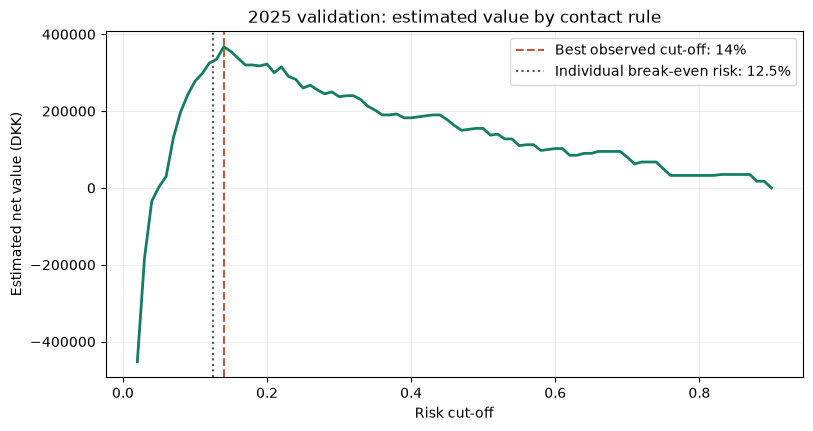

Best cut-off under stated assumptions: 14%; estimated net value 367,500 DKK; contact 149 students.
Individual break-even risk from the assumptions: 12.5%.
If a false alarm costs 10,000 DKK: best cut-off 66%; contact 10 students.


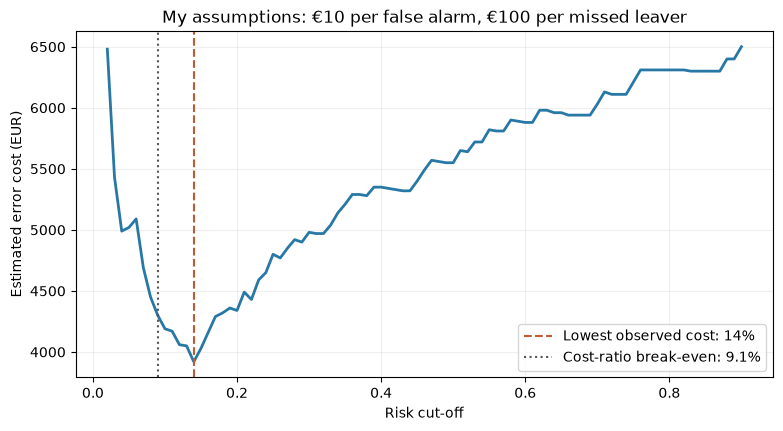

My cost-ratio break-even cut-off is 9.1%; lowest validation error cost on the tested grid is at 14%.
At that cut-off: 112 false alarms and 28 missed leavers; estimated error cost €3,920.
At 50% the estimated error cost is €5,550.
This personal scenario includes only the stated FP/FN error costs; it does not add the assignment's separate conversation cost or intervention-effect assumptions.


In [16]:
cost_thresholds = np.round(np.arange(0.02, 0.901, 0.01), 2)

def net_value_at(cut, worry_cost=COST_WORRY, help_rate=HELPS):
    counts = boxes(cut)
    return (
        counts["TP"] * help_rate * COST_LEAVE
        - counts["contacted"] * COST_TALK
        - counts["FP"] * worry_cost
    )

net_values = pd.Series(
    [net_value_at(cut) for cut in cost_thresholds],
    index=cost_thresholds,
    name="net_value_dkk",
)
best_cut = float(net_values.idxmax())
best_counts = boxes(best_cut)
break_even = (COST_TALK + COST_WORRY) / (HELPS * COST_LEAVE + COST_WORRY)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(net_values.index, net_values.values, color="#147d64", linewidth=2)
ax.axvline(best_cut, color="#bd5b35", linestyle="--", label=f"Best observed cut-off: {best_cut:.0%}")
ax.axvline(break_even, color="#555555", linestyle=":", label=f"Individual break-even risk: {break_even:.1%}")
ax.set(xlabel="Risk cut-off", ylabel="Estimated net value (DKK)", title="2025 validation: estimated value by contact rule")
ax.legend()
ax.grid(alpha=0.2)
plt.show()

high_worry_values = pd.Series(
    [net_value_at(cut, worry_cost=10_000) for cut in cost_thresholds],
    index=cost_thresholds,
)
high_worry_cut = float(high_worry_values.idxmax())
high_worry_counts = boxes(high_worry_cut)

print(f"Best cut-off under stated assumptions: {best_cut:.0%}; estimated net value {net_values.max():,.0f} DKK; contact {best_counts['contacted']} students.")
print(f"Individual break-even risk from the assumptions: {break_even:.1%}.")
print(f"If a false alarm costs 10,000 DKK: best cut-off {high_worry_cut:.0%}; contact {high_worry_counts['contacted']} students.")

# Personal error-cost scenario, kept separate from the assignment's DKK assumptions.
PERSONAL_FP_COST_EUR = 10
PERSONAL_FN_COST_EUR = 100
personal_break_even = PERSONAL_FP_COST_EUR / (PERSONAL_FP_COST_EUR + PERSONAL_FN_COST_EUR)
personal_error_costs = pd.Series(
    [
        boxes(cut)["FP"] * PERSONAL_FP_COST_EUR
        + boxes(cut)["FN"] * PERSONAL_FN_COST_EUR
        for cut in cost_thresholds
    ],
    index=cost_thresholds,
    name="estimated_error_cost_eur",
)
personal_best_cut = float(personal_error_costs.idxmin())
personal_best_counts = boxes(personal_best_cut)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(personal_error_costs.index, personal_error_costs.values, color="#2878a5", linewidth=2)
ax.axvline(personal_best_cut, color="#bd5b35", linestyle="--", label=f"Lowest observed cost: {personal_best_cut:.0%}")
ax.axvline(personal_break_even, color="#555555", linestyle=":", label=f"Cost-ratio break-even: {personal_break_even:.1%}")
ax.set(xlabel="Risk cut-off", ylabel="Estimated error cost (EUR)", title="My assumptions: €10 per false alarm, €100 per missed leaver")
ax.legend()
ax.grid(alpha=0.2)
plt.show()

personal_cost_at_50 = boxes(0.5)["FP"] * PERSONAL_FP_COST_EUR + boxes(0.5)["FN"] * PERSONAL_FN_COST_EUR
print(f"My cost-ratio break-even cut-off is {personal_break_even:.1%}; lowest validation error cost on the tested grid is at {personal_best_cut:.0%}.")
print(f"At that cut-off: {personal_best_counts['FP']} false alarms and {personal_best_counts['FN']} missed leavers; estimated error cost €{personal_error_costs.min():,.0f}.")
print(f"At 50% the estimated error cost is €{personal_cost_at_50:,.0f}.")
print("This personal scenario includes only the stated FP/FN error costs; it does not add the assignment's separate conversation cost or intervention-effect assumptions.")

In [17]:
capacity_top40 = val.nlargest(40, "risk")
capacity_tp = int(capacity_top40["left"].sum())
capacity_fp = len(capacity_top40) - capacity_tp
capacity_fn = int(val["left"].sum()) - capacity_tp
capacity_personal_cost = capacity_fp * PERSONAL_FP_COST_EUR + capacity_fn * PERSONAL_FN_COST_EUR
print(f"With only 40 conversations: {capacity_fp} false alarms and {capacity_fn} missed leavers, or estimated error cost €{capacity_personal_cost:,.0f}.")
print(f"The 14% cost-minimizing rule contacts {personal_best_counts['contacted']} students, so it exceeds capacity by {personal_best_counts['contacted'] - 40}.")

With only 40 conversations: 26 false alarms and 51 missed leavers, or estimated error cost €5,360.
The 14% cost-minimizing rule contacts 149 students, so it exceeds capacity by 109.


*Your answer:*

Under the assignment's DKK assumptions, the best tested cut-off is **14%**, with an estimated net value of **367,500 DKK** and **149 contacts**. The individual break-even risk is **12.5%**; the empirical best is slightly higher because the validation scores are discrete. If a false alarm is valued at 10,000 DKK, the best tested cut-off moves to **66%** and contacts **10 students**. Neither cost calculation fits the 40-conversation limit as stated.

Using my separate estimates of **€10 per false alarm** and **€100 per missed leaver**, the cost-ratio break-even cut-off is **9.1%** if contact itself has no additional cost. On the tested 2025 cut-offs, the lowest error cost is at **14%**: 112 false alarms and 28 missed leavers, an estimated **€3,920**. At 50%, the estimated error cost is **€5,550**. With the actual capacity of 40 conversations, the top-40 rule has 26 false alarms and 51 missed leavers, an estimated **€5,360**; the 14% rule is not feasible because it would require 149 contacts. This euro calculation counts only the stated false-positive and false-negative costs; it does not include a separate cost for successful conversations or an intervention benefit, so it should not be compared directly with the DKK scenario.

Students, advisers, university leadership, and student-support representatives should agree on these values; they encode policy choices and uncertain assumptions, not objective model facts.

---
## 7 · Only 40 conversations

The office can talk to **40** students at week 6. With a fixed capacity the rule becomes: **talk to the 40 with the
highest risk**. How many of the 40 were really at risk (**precision at 40**)? How many of all students who left were
among them (**recall at 40**)?

✏️ **Your turn.** Compute precision and recall at 40. How many conversations would you need to reach half of the students who leave? What would a fourth adviser (about 13 more conversations) buy?

<details><summary>Hint</summary>

`top = val.nlargest(40, 'risk')`; precision = `top['left'].mean()`; recall = `top['left'].sum() / val['left'].sum()`. Try other numbers instead of 40.
</details>

In [12]:
top40 = val.nlargest(40, "risk").copy()
precision_at_40 = top40["left"].mean()
recall_at_40 = top40["left"].sum() / val["left"].sum()

ordered = val.sort_values("risk", ascending=False)
leavers_total = int(val["left"].sum())
half_target = int(np.ceil(leavers_total / 2))
cumulative_reached = ordered["left"].cumsum().to_numpy()
conversations_for_half = int(np.searchsorted(cumulative_reached, half_target) + 1)

fourth_adviser_capacity = 53
top53 = ordered.head(fourth_adviser_capacity)
reached_by_40 = int(top40["left"].sum())
reached_by_53 = int(top53["left"].sum())

print(f"At 40 conversations: {int(top40['left'].sum())} of 40 students later left (precision {precision_at_40:.1%}).")
print(f"That reaches {reached_by_40} of {leavers_total} leavers (recall {recall_at_40:.1%}).")
print(f"To reach at least half of the {leavers_total} leavers in this validation cohort, the ranking needs {conversations_for_half} conversations.")
print(f"A fourth adviser adds 13 places (capacity {fourth_adviser_capacity}): {reached_by_53 - reached_by_40} additional leavers reached, {reached_by_53} total.")

At 40 conversations: 14 of 40 students later left (precision 35.0%).
That reaches 14 of 65 leavers (recall 21.5%).
To reach at least half of the 65 leavers in this validation cohort, the ranking needs 122 conversations.
A fourth adviser adds 13 places (capacity 53): 4 additional leavers reached, 18 total.


*Your answer:*

With 40 conversations, **14 of 40** later left (precision **35.0%**) and we reach **14 of 65** leavers (recall **21.5%**). The ranking needs **122 conversations** to reach at least half of the 2025 leavers. A fourth adviser adds 13 places and reaches about **4 additional leavers** in this validation cohort (18 total among the top 53). These are retrospective estimates; they do not show that a conversation itself prevents leaving.

---
## 8 · Fair to whom? ⚖️

About a fifth of the students are international. Compare the mistakes **per group** for the top-40 rule.

✏️ **Your turn.** For international and domestic students: the share who really leave, the average predicted risk, and the recall of the top-40 rule. Does the model get both groups right? Then compare how often each group logs in. Is a login the same signal for everyone? What would you tell the university?

<details><summary>Hint</summary>

Mark the top 40 first: `val['top40'] = val['risk'].rank(ascending=False) <= 40`. Then `val.groupby('international')[['left', 'risk']].mean()`; recall per group = among the students who left, the share with `top40`: `val[val['left'] == 1].groupby('international')['top40'].mean()`. Logins: `history.groupby('international')['logins_total'].mean()`.
</details>

In [13]:
val["top40"] = val["risk"].rank(method="first", ascending=False) <= 40

by_group = val.groupby("international", observed=True).agg(
    students=("left", "size"),
    observed_leave_rate=("left", "mean"),
    mean_predicted_risk=("risk", "mean"),
)
by_group["recall_at_40"] = val[val["left"] == 1].groupby("international", observed=True)["top40"].mean()
by_group.index = ["Domestic" if group == 0 else "International" for group in by_group.index]

login_by_group = history.groupby("international", observed=True)["logins_total"].agg(["count", "mean"])
login_by_group.index = ["Domestic" if group == 0 else "International" for group in login_by_group.index]

print("2025 outcomes and top-40 recall by group:")
display(by_group)
print("\nMean total logins by group across 2023-2025:")
display(login_by_group)

2025 outcomes and top-40 recall by group:


,students,observed_leave_rate,mean_predicted_risk,recall_at_40
Domestic,738,0.069106,0.088053,0.235294
International,199,0.070352,0.072063,0.142857



Mean total logins by group across 2023-2025:


,count,mean
Domestic,2085,36.446523
International,601,23.622296


*Your answer:*

The 2025 leave rates were similar (**6.9% domestic; 7.0% international**), but top-40 recall was **23.5% for domestic leavers** and **14.3% for international leavers**. The average predicted risks were 8.8% and 7.2%, respectively. In the historical data, international students averaged about **23.6 logins** versus **36.4** for domestic students. So login volume is not an equally distributed signal, and the current top-40 rule reaches the groups differently. This small holdout does not settle fairness; the university should investigate calibration and recall with more cohorts and students, ask affected groups, monitor the results, and keep a human review before any outreach decision.

---
## 9 · Store the model

The app needs your model as files. Do it the way the hotel notebook (session 10) does in section 9, *Storing the model properly*: the
**portable copy** (`preprocess.json` + `booster.json`) loads in the app with any Python version, which a pickle does
not. The hotel app's `portable.py` does both the saving and the loading, for a pipeline built like the one in step 4.

✏️ **Your turn.** Save your XGBoost pipeline into a folder `model`, load it back with `portable.Model`, and check that it gives the same predictions. Download the folder as a zip. You will put it into your app's repository.

<details><summary>Hint</summary>

```python
import urllib.request, shutil
urllib.request.urlretrieve("https://raw.githubusercontent.com/aaubs/tonights-front-desk/main/portable.py", "portable.py")
import portable
os.makedirs("model", exist_ok=True)
portable.export(booster, "model")
back = portable.Model("model").predict_proba(val)
print(np.allclose(back, booster.predict_proba(val[features])[:, 1], atol=1e-5))
shutil.make_archive("model", "zip", "model")   # then download model.zip (Colab: the folder icon on the left)
```
</details>

In [14]:
import shutil
import urllib.request

portable_url = "https://raw.githubusercontent.com/aaubs/tonights-front-desk/main/portable.py"
if not os.path.exists("portable.py"):
    urllib.request.urlretrieve(portable_url, "portable.py")

import portable

os.makedirs("model", exist_ok=True)
portable.export(booster, "model")
portable_model = portable.Model("model")
portable_risk = portable_model.predict_proba(val[features])

same_predictions = np.allclose(portable_risk, xgb_risk, atol=1e-5)
print("Portable model matches the in-notebook XGBoost probabilities:", same_predictions)
if not same_predictions:
    raise AssertionError("Portable export predictions differ from the fitted pipeline.")

model_zip = shutil.make_archive("model", "zip", "model")
print("Created portable model files:", sorted(os.listdir("model")))
print("Created archive:", model_zip)

Portable model matches the in-notebook XGBoost probabilities: True
Created portable model files: ['booster.json', 'preprocess.json']
Created archive: c:\Users\karol\Businessdatascience\Dropout predictor\model.zip


---
## 10 · This week's list

Now use the model the way the office would: on the 2026 students at the end of week 6.

✏️ **Your turn.** Predict the risk for every student in `new`, and show the 40 students the office should talk to this week. Would you send all 40 the same message? Is there anyone you would *not* contact?

<details><summary>Hint</summary>

`new['risk'] = booster.predict_proba(new[features])[:, 1]`, then `new.nlargest(40, 'risk')`.
</details>

In [15]:
new["risk"] = portable_model.predict_proba(new[features])
new["priority"] = new["risk"].rank(method="first", ascending=False).astype(int)
recommended = new.nsmallest(40, "priority").copy()

show_columns = [
    column for column in [
        "priority", "student_id", "risk", "programme", "fees_owed",
        "submitted_share", "missed_last3", "logins_last3", "weeks_since_login",
    ]
    if column in recommended.columns
]
print(f"2026 students: {len(new):,}; recommended for the 40 available conversations:")
display(recommended[show_columns].reset_index(drop=True))

2026 students: 703; recommended for the 40 available conversations:


,priority,student_id,risk,programme,fees_owed,submitted_share,missed_last3,logins_last3,weeks_since_login
0,1,S260271,0.922764,Communication & Digital Media,1,0.33,3.0,6.0,1.0
1,2,S260281,0.886610,Business Administration,0,0.50,2.0,8.0,0.0
2,3,S260391,0.880409,Communication & Digital Media,1,0.50,1.0,7.0,0.0
3,4,S260648,0.845881,Tourism,1,0.17,3.0,3.0,0.0
4,5,S260458,0.691558,Communication & Digital Media,1,0.50,1.0,0.0,3.0
5,6,S260529,0.629838,Business Administration,0,0.50,2.0,6.0,0.0
6,7,S260335,0.616807,Sustainable Biotechnology,0,0.83,1.0,16.0,0.0
7,8,S260417,0.561802,Business Administration,0,0.50,2.0,7.0,0.0
8,9,S260223,0.560960,Social Work,1,0.67,2.0,7.0,0.0
9,10,S260696,0.535510,Sustainable Biotechnology,0,0.33,3.0,6.0,0.0


*Your answer:*

The list ranks all **703** students, with the 40 highest risks marked for the available conversations. I would not send everyone the same message: invite each student to an optional, private conversation, adapt the support to what they say they need, and avoid labelling them as likely to drop out. A human adviser should review the list and the observable week-6 context first. The lowest-ranked student among the 40 has a predicted risk of about **34%**, so there is no sharp natural boundary; capacity, student preference, and the risk of unfairly missing someone should be discussed before acting.

---
## 11 · Build the app 🛠️

Now build a Streamlit app for someone at the study office who is **not** a data scientist. Use the hotel app as your
template: [github.com/aaubs/tonights-front-desk](https://github.com/aaubs/tonights-front-desk) (`app.py`, `portable.py`,
`requirements.txt`, `model/`).

Your app should at least show:

1. **This week's list**: the 2026 students, ranked by risk, with the top 40 marked.
2. **The mistakes of a rule**: a slider (cut-off, or number of conversations) and, on the 2025 cohort, the four boxes
   in plain words ("12 students reached in time, 28 worried for nothing, 30 missed"), precision and recall.
3. **Per group**: the same numbers for international and domestic students.
4. **One thing of your own** that would help the office decide (for example the costs from step 6 as inputs, or why
   a student is on the list).

The app can read the data straight from GitHub, like this notebook (`URL + "new_week6.csv"`).

**Deploy:** create a public GitHub repository with `app.py`, `portable.py`, `requirements.txt` (`streamlit`,
`pandas`, `xgboost-cpu`, no version numbers) and your `model/` folder; then on
[share.streamlit.io](https://share.streamlit.io): *Create app* → your repository → `app.py`.